In [39]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [76]:
import os
import copy
import platform
import subprocess
import json
from io import StringIO
import numpy as np
import pandas as pd
import networkx as nx
from networkx.readwrite import json_graph
from pathlib import Path


from html_from_assignments import NMRProblem
import jsonUtils

import nmrsolution
# from globals import svgDimensions

from globals import SVG_DIMENSIONS as svgDimensions
from simulatedAnnealing_v5 import SimulatedAnnealing2

import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

/Users/vsmw51/Library/CloudStorage/OneDrive-DurhamUniversity/projects/programming/2025/python/awh/simpleNMRtools2/nmrsolution.py:2389: SyntaxWarning: invalid escape sequence '\s'
  print("n\self.hmbc.columns:\n", self.hmbc.columns)


In [77]:
%matplotlib inline

In [78]:
platform.system()

'Darwin'

In [79]:
if platform.system() == "Darwin":

    fn_json = Path("/Users/vsmw51/Downloads/4Eric/caryophyllene/caryophyllene_assignments_mresnova.json")
    fn_json = Path("/Users/vsmw51/Downloads/4Eric/caryophyllene/caryophyllene_assignments_mresnova.json")
    fn_json = Path("/Users/vsmw51/OneDrive - Durham University/projects/programming/2025/python/awh/bruker_data_sets/E72507_04164043_propyl_benzoate/04164043/04164043_assignments.json")
    fn_json = Path("/opt/topspin4.5.0/examdata/exam_CMCse_1/exam_CMCse_1_assignments.json")
    fn_json = Path("/Users/vsmw51/Dropbox/4Eric/Cytochalasin-B3/Cytochalasin-B_assignments_mresnova.json")
    fn_json = Path("/Users/vsmw51/Dropbox/4Eric/Cytochalasin-B-kate/Cytochalasin-B-kate_assignments_mresnova.json")
    fn_json = Path("/Users/vsmw51/Dropbox/4Eric/menthol/menthol_assignments_mresnova.json")


elif platform.system() == "Windows":
    fn_json = Path(r"C:\Users\vsmw51\OneDrive - Durham University\projects\programming\2025\python\awh\bruker_data_sets\E72507_04164043_propyl_benzoate\04164043\04164043_jeol_inputdata.json")
    

In [136]:
with open(fn_json, 'r') as f:
    json_data = json.load(f)

/Users/vsmw51/Library/CloudStorage/OneDrive-DurhamUniversity/projects/programming/2025/python/awh/simpleNMRtools2/nmrsolution.py:2385: SyntaxWarning: invalid escape sequence '\s'
  self.hmbc["f2H_i"] = ""


In [137]:
json_data.keys()

dict_keys(['smiles', 'molfile', 'hostname', 'allAtomsInfo', 'carbonAtomsInfo', 'nmrAssignments', 'c13predictions', '04162544.10.fid_0', '04162544.11.1.1r_1', 'chosenSpectra', 'SKIP_0', 'HSQC_0', 'HMBC_0', 'HSQC_CLIPCOSY_0', 'DDEPTCH3ONLY_0', 'MNOVAcalcMethod', 'exptIdentifiers', 'workingDirectory', 'workingFilename', 'simulatedAnnealing', 'ml_consent', 'spectraWithPeaks'])

In [138]:
problemdata_json = NMRProblem.from_mnova_dict(json_data)


from_mnova_dict(cls,json_data: dict):

Processing key: smiles
	data[smiles].keys()
 dict_keys(['datatype', 'count', 'data']) 

v.items():
 dict_items([('datatype', 'smiles'), ('count', 1), ('data', {'0': 'CC(C)C1CCC(C)CC1O'})]) 

Processing key: molfile
	data[molfile].keys()
 dict_keys(['datatype', 'count', 'data']) 

v.items():
 dict_items([('datatype', 'molfile'), ('count', 1), ('data', {'0': '\r\n  E 2024-003132612042D\r\n\r\n 11 11  0  0  0  0  0  0  0  0999 V2000\r\n    3.6373    2.1000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\r\n    3.6373    3.5000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\r\n    2.4249    4.2000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\r\n    1.2124    3.5000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\r\n    1.2124    2.1000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\r\n    2.4249    1.4000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\r\n    2.4249    5.6000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\r\n    3.6373  

In [139]:
type(problemdata_json)

html_from_assignments.NMRProblem

In [140]:
problemdata_json.dataframes.keys()

dict_keys(['smiles', 'molfile', 'allAtomsInfo', 'carbonAtomsInfo', 'nmrAssignments', 'c13predictions', 'chosenSpectra', 'MNOVAcalcMethod', 'workingDirectory', 'workingFilename', 'simulatedAnnealing', 'spectraWithPeaks', 'molecule', 'HSQC', 'HMBC', 'HSQC_CLIPCOSY', 'DDEPTCH3ONLY', 'H1_1D', 'C13_1D', 'DEPT135', 'H1_pureshift', 'COSY', 'NOESY'])

In [141]:
problemdata_json.dataframes['HMBC']

,f2_ppm,f1_ppm,intensity,signaltype,Annotation
1,3.340070,49.995083,6.825525,0,
2,3.340070,44.996140,5.834052,0,
3,2.159348,71.297755,8.801840,0,
4,2.159348,49.995083,7.782452,0,
5,2.159348,15.971817,4.227268,0,
6,2.159348,21.010441,8.975086,0,
7,2.159348,23.055968,21.749950,0,
8,1.919587,49.995083,4.836663,0,
9,1.919587,71.297755,4.906383,0,
10,1.565500,71.297755,15.852588,0,


In [142]:
problemdata_json.dataframes['C13_1D']

,ppm,intensity,Width,Area,signaltype,Flags,Impurity/Compound,Annotation


In [143]:
problemdata_json.dataframes['HSQC_CLIPCOSY']

,f2_ppm,f1_ppm,intensity,signaltype,Annotation
1,3.340070,49.995083,-36.832912,0,
2,3.340070,44.996140,-44.408642,0,
3,2.159348,21.010441,-49.671371,0,
4,2.159348,15.971817,-39.915237,0,
5,1.370247,44.996140,-34.752796,0,
6,1.370247,34.544561,-20.817665,0,
7,1.370247,22.190061,-26.670502,0,
8,1.071779,23.055968,-38.486485,0,
9,0.926000,49.995083,-13.706235,0,
10,0.926000,34.544561,-18.954357,0,


In [144]:
problemdata_json.dataframes['HSQC']

,f2_ppm,f1_ppm,intensity,signaltype,Annotation
1,3.340070,71.297755,9006.562377,0,
2,2.159348,25.620159,8072.548901,0,
3,1.919587,44.996140,-7361.668745,0,
4,1.616411,34.544561,-6248.385692,0,
5,1.565500,23.055968,-5925.086959,0,
6,1.370247,31.637562,5689.283976,0,
7,1.071779,49.995083,6297.671887,0,
8,0.926000,23.055968,-4081.992449,0,
9,0.916205,44.996140,-5250.686930,0,
10,0.883488,21.010441,19914.904717,0,


In [145]:
problemdata_json.dataframes['DDEPTCH3ONLY']

,f2_ppm,f1_ppm,intensity,signaltype,Annotation
1,0.883488,21.010441,94753.093750,0,
2,0.867698,22.190061,221003.093750,0,
3,0.760811,15.971817,147066.984375,0,


In [146]:
dir(problemdata_json)

['JEOL_prediction_used',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'add_missing_spectra',
 'carbonSeparation',
 'dataframes',
 'exact_ppm_values',
 'exact_ppm_values_only',
 'from_excel_file',
 'from_mnova_dict',
 'from_mnova_json_file',
 'get_molfile_string',
 'is_prediction',
 'json_data',
 'prediction_from_nmrshiftdb2',
 'prepare_network_graph',
 'protonSeparation']

In [147]:
solution = nmrsolution.NMRsolution(problemdata_json)

self.expts_available {'DDEPTCH3ONLY', 'HSQC_CLIPCOSY', 'SKIP', 'HSQC', 'HMBC'}
problemdata_json.dataframes.keys() dict_keys(['smiles', 'molfile', 'allAtomsInfo', 'carbonAtomsInfo', 'nmrAssignments', 'c13predictions', 'chosenSpectra', 'MNOVAcalcMethod', 'workingDirectory', 'workingFilename', 'simulatedAnnealing', 'spectraWithPeaks', 'molecule', 'HSQC', 'HMBC', 'HSQC_CLIPCOSY', 'DDEPTCH3ONLY', 'H1_1D', 'C13_1D', 'DEPT135', 'H1_pureshift', 'COSY', 'NOESY'])
Prediction from NMRSHIFTDB2
Prediction from NMRSHIFTDB2
BEFORE ::: self.molprops_df
    idx  atom_idx  implicitHs  totalNumHs  degree  hybridization  aromatic
0    0         0           2           2       2              4     False
1    1         1           2           2       2              4     False
2    2         2           1           1       3              4     False
3    3         3           1           1       3              4     False
4    4         4           2           2       2              4     False
5    5      

In [148]:
solution.ddept_ch3_only_df.head()

,f2_ppm,f1_ppm,intensity,signaltype,Annotation
1,0.883488,21.010441,94753.093750,0,
2,0.867698,22.190061,221003.093750,0,
3,0.760811,15.971817,147066.984375,0,


In [149]:
solution.hsqc_df

,f2_ppm,f1_ppm,intensity,signaltype,Annotation
1,3.340070,71.297755,9006.562377,0,
2,2.159348,25.620159,8072.548901,0,
3,1.919587,44.996140,-7361.668745,0,
4,1.616411,34.544561,-6248.385692,0,
5,1.565500,23.055968,-5925.086959,0,
6,1.370247,31.637562,5689.283976,0,
7,1.071779,49.995083,6297.671887,0,
8,0.926000,23.055968,-4081.992449,0,
9,0.916205,44.996140,-5250.686930,0,
10,0.883488,21.010441,19914.904717,0,


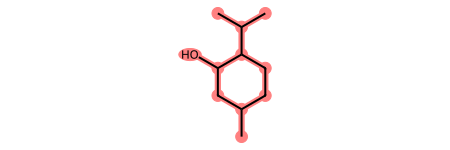

In [150]:
solution.expected_molecule

In [151]:
solution.nmrsolution_failed

False

In [152]:
solution.expected_molecule.nmrshiftdb_failed

False

In [153]:
ok, msg = solution.init_class_from_json()
ok,msg

self.HSQC_data_present: True
self.hsqc_df:
       f2_ppm     f1_ppm     intensity  signaltype Annotation
1   3.340070  71.297755   9006.562377           0           
2   2.159348  25.620159   8072.548901           0           
3   1.919587  44.996140  -7361.668745           0           
4   1.616411  34.544561  -6248.385692           0           
5   1.565500  23.055968  -5925.086959           0           
6   1.370247  31.637562   5689.283976           0           
7   1.071779  49.995083   6297.671887           0           
8   0.926000  23.055968  -4081.992449           0           
9   0.916205  44.996140  -5250.686930           0           
10  0.883488  21.010441  19914.904717           0           
11  0.867698  22.190061  20980.060080           0           
12  0.800060  34.544561  -4464.282671           0           
13  0.760811  15.971817  21156.370186           0           
p0 44.99614030315194 <class 'float'>
p0 34.544561149385736 <class 'float'>
p0 23.055968024339805 <clas

/Users/vsmw51/Library/CloudStorage/OneDrive-DurhamUniversity/projects/programming/2025/python/awh/simpleNMRtools2/nmrsolution.py:1461: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '79.78845608028654' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  )
/Users/vsmw51/Library/CloudStorage/OneDrive-DurhamUniversity/projects/programming/2025/python/awh/simpleNMRtools2/nmrsolution.py:1461: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '159.57691216057307' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  )
/Users/vsmw51/Library/CloudStorage/OneDrive-DurhamUniversity/projects/programming/2025/python/awh/simpleNMRtools2/nmrsolution.py:1461: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pa


Filling in hmbc dataframe with index columns

n\self.hmbc.columns:
 Index(['f1_ppm', 'f2_ppm', 'intensity', 'f2p_ppm', 'f1_i', 'f2_i', 'f2p_i',
       'f1_ppm_orig', 'f1_ppm_prob', 'f2_ppm_orig', 'f2_ppm_prob', 'f1C_i',
       'f2H_i', 'f2Cp_i'],
      dtype='object')

       f1_ppm    f2_ppm
1   49.995083  3.340070
2   44.996140  3.340070
3   71.297755  2.159348
4   49.995083  2.159348
5   15.971817  2.159348
6   21.010441  2.159348
7   23.055968  2.159348
8   49.995083  1.919587
9   71.297755  1.919587
10  71.297755  1.565500
11  49.995083  1.565500
12  25.620159  0.883488
13  15.971817  0.883488
14  49.995083  0.883488
15  31.637562  0.867698
16  34.544561  0.867698
17  44.996140  0.867698
18  25.620159  0.760811
19  49.995083  0.760811
20  21.010441  0.760811
self.hsqcH1ppmC13ppm:

3.34007044792381: 71.29775511668124
2.1593477150762146: 25.620159239844863
1.919587300429365: 44.99614030315194
1.6164108203742011: 34.544561149385736
1.5654996289887224: 23.055968024339805
1.3702469164

/Users/vsmw51/Library/CloudStorage/OneDrive-DurhamUniversity/projects/programming/2025/python/awh/simpleNMRtools2/nmrsolution.py:2514: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '71.29775511668124' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  hsqc.f2_ppm, hsqc.f1_ppm, hsqc.f2p_ppm, hsqc.f2p_i, hsqc.f1_i, hsqc.f2_i
/Users/vsmw51/Library/CloudStorage/OneDrive-DurhamUniversity/projects/programming/2025/python/awh/simpleNMRtools2/nmrsolution.py:2472: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  # Remove columns in df that are not in the cosy dataframe
/Users/vsmw51/Library/CloudStorage/OneDrive-DurhamUniversity/proje

(True, 'ok')

In [154]:
solution.hsqc[solution.hsqc.CH3][['f2_ppm', 'f1_ppm', 'CH0', 'CH1', 'CH2', 'CH3', 'numProtons']]

,f2_ppm,f1_ppm,CH0,CH1,CH2,CH3,numProtons
10,0.883488,21.010441,False,False,False,True,-1
11,0.867698,22.190061,False,False,False,True,-1
13,0.760811,15.971817,False,False,False,True,-1


In [155]:
rtn_msg, rtn_num = solution.assign_CH3_CH2_CH1_overall()
rtn_msg, rtn_num

assign_CH3_CH2_CH1_in_HSQC_using_Assignments
c13_from_hsqc and H1_data_missing
CH1_mol_df.shape[0]: 4
num_CH3CH1_hsqc: 7
CH3CH1_hsqc_df.shape[0]: 7
CH3CH1_mol_df.shape[0]: 7
CH3CH1_sym_mol_df.shape[0]: 6
CH3 groups already assigned
ok 200


('ok', 200)

In [156]:
solution.hsqc[solution.hsqc.CH3][['f2_ppm', 'f1_ppm', 'CH0', 'CH1', 'CH2', 'CH3', 'numProtons']]

,f2_ppm,f1_ppm,CH0,CH1,CH2,CH3,numProtons
10,0.883488,21.010441,False,False,False,True,3
11,0.867698,22.190061,False,False,False,True,3
13,0.760811,15.971817,False,False,False,True,3


In [157]:
solution.assign_CH3_CH2_CH1_in_HSQC_using_Assignments()

assign_CH3_CH2_CH1_in_HSQC_using_Assignments


In [158]:
solution.hsqc[solution.hsqc.CH3][['f2_ppm', 'f1_ppm', 'CH0', 'CH1', 'CH2', 'CH3', 'numProtons']]

,f2_ppm,f1_ppm,CH0,CH1,CH2,CH3,numProtons
10,0.883488,21.010441,False,False,False,True,3
11,0.867698,22.190061,False,False,False,True,3
13,0.760811,15.971817,False,False,False,True,3


In [159]:
solution.assign_CH3_CH1_in_HSQC_using_H1()

In [160]:
solution.hsqc[solution.hsqc.CH3][['f2_ppm', 'f1_ppm', 'CH0', 'CH1', 'CH2', 'CH3', 'numProtons']]

,f2_ppm,f1_ppm,CH0,CH1,CH2,CH3,numProtons
10,0.883488,21.010441,False,False,False,True,3
11,0.867698,22.190061,False,False,False,True,3
13,0.760811,15.971817,False,False,False,True,3


In [161]:
solution.assign_CH3_CH1_in_HSQC_using_expected_molecule()

c13_from_hsqc and H1_data_missing
CH1_mol_df.shape[0]: 4
num_CH3CH1_hsqc: 7
CH3CH1_hsqc_df.shape[0]: 7
CH3CH1_mol_df.shape[0]: 7
CH3CH1_sym_mol_df.shape[0]: 6
CH3 groups already assigned


In [162]:
solution.hsqc[solution.hsqc.CH3][['f2_ppm', 'f1_ppm', 'CH0', 'CH1', 'CH2', 'CH3', 'numProtons']]

,f2_ppm,f1_ppm,CH0,CH1,CH2,CH3,numProtons
10,0.883488,21.010441,False,False,False,True,3
11,0.867698,22.190061,False,False,False,True,3
13,0.760811,15.971817,False,False,False,True,3


In [164]:
solution.c13

,ppm,numProtons,attached_protons,CH0,CH1,CH2,CH3,CH3CH1,quaternary,ppmH1s,max_bonds,label,f2C_i,f1C_i,f1_i,f2_i
1,71.297755,-1,0,False,False,False,False,False,False,None,4,C1,C1,C1,1,1
2,49.995083,-1,0,False,False,False,False,False,False,None,4,C2,C2,C2,2,2
3,44.996140,2,0,False,False,True,False,False,False,None,4,C3,C3,C3,3,3
4,34.544561,2,0,False,False,True,False,False,False,None,4,C4,C4,C4,4,4
5,31.637562,-1,0,False,False,False,False,False,False,None,4,C5,C5,C5,5,5
6,25.620159,-1,0,False,False,False,False,False,False,None,4,C6,C6,C6,6,6
7,23.055968,2,0,False,False,True,False,False,False,None,4,C7,C7,C7,7,7
8,22.190061,-1,0,False,False,False,False,False,False,None,4,C8,C8,C8,8,8
9,21.010441,-1,0,False,False,False,False,False,False,None,4,C9,C9,C9,9,9
10,15.971817,-1,0,False,False,False,False,False,False,None,4,C10,C10,C10,10,10


In [168]:
solution.numCarbonGroups

10

In [171]:
solution.carbonAtomsInfo.shape[0]

10

In [176]:
solution.expected_molecule.num_carbon_atoms, solution.expected_molecule.num_sym_carbon_atoms

(10, 9)

In [174]:
dir(solution.expected_molecule)

['GetAromaticAtoms',
 'GetAtomWithIdx',
 'GetAtoms',
 'GetBondBetweenAtoms',
 'GetBondWithIdx',
 'GetBonds',
 'GetConformer',
 'GetNumAtoms',
 'GetNumBonds',
 'GetRingInfo',
 'GetRingSystems',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_repr_png_',
 '_repr_svg_',
 'add_ring_info_to_dataframe',
 'c13_nmr_shifts',
 'c13ppm',
 'calc_allatom_xy_positions_png',
 'calc_carbon_xy_positions_png',
 'calc_dbe',
 'calculated_c13_chemical_shifts',
 'copy_xy3_to_molecule',
 'create_png',
 'create_svg_string',
 'dbe',
 'elements',
 'has_hose_code_symmetry',
 'has_symmetry',
 'init_elements_dict',
 'map_symmetric_ar

In [100]:
solution.transfer_hsqc_info_to_c13()
solution.transfer_hsqc_info_to_h1()

In [101]:
solution.initialise_prior_to_carbon_assignment()

('ok', 200)

In [102]:
rtn_msg, rtn_num = solution.attempt_assignment_CH3_CH2_CH1_to_C13_table()
rtn_msg, rtn_num

CH0 c13_CHn is empty


('ok', 200)

In [103]:
solution.update_assignments_expt_dataframes()

In [21]:
G2 = nmrsolution.create_network_graph(solution.c13, solution.h1)
G2 = nmrsolution.add_all_cosy_edges_to_graph(
    G2, solution.cosy, solution.hsqc_clipcosy, solution.h1
)
G2 = nmrsolution.add_all_hmbc_edges_to_graph(
    G2, solution.hmbc, solution.h1, solution.c13
)

Adding HMBC edges 1


In [22]:
jsonGraphData = json_graph.node_link_data(G2) # reverted back to original as edges="links" was causing problems
jsonGraphData["moved_nodes"] = jsonGraphData["nodes"]
solution.initiate_molgraph( json_data, G2)

#  convert the molgraph to a json object
jsonGraphData_mol = json_graph.node_link_data(solution.molgraph) # reverted back to original as edges="links" was causing problems

# calculate the shortest paths between all pairs of nodes in the molgraph
shortest_paths = dict(nx.all_pairs_dijkstra_path_length(solution.molgraph))

/Users/vsmw51/opt/anaconda3/envs/py313/lib/python3.13/site-packages/networkx/readwrite/json_graph/node_link.py:142: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(


In [23]:
svgWidth = svgDimensions.svg_width
svgHeight = svgDimensions.svg_height
molWidth = svgDimensions.mol_width
molHeight = svgDimensions.mol_height

catoms_df = solution.expected_molecule.molprops_df[
    [
        "ppm",
        "atom_idx",
        "atomNumber",
        "numProtons",
        "x",
        "y",
        'sym_atom_idx',
        'sym_atomNumber',
    ]
].copy()

# rename ppm to ppm_calculated
catoms_df.rename(columns={"ppm": "ppm_calculated"}, inplace=True)
# renam atom_idx to id
catoms_df.rename(columns={"atom_idx": "id"}, inplace=True)

# add columns ppm, jCouplingVals, jCouplingClass, visible, H1_ppm
catoms_df["ppm"] = -1000000.0
catoms_df["jCouplingVals"] = ""
catoms_df["jCouplingClass"] = ""
catoms_df["visible"] = "false"
catoms_df["symbol"] = "C"
catoms_df["iupacLabel"] = ""

# catoms_str = json.dumps(catoms_df.to_dict(orient="records"), indent=4)
json_data_str = json.dumps(json_data, indent=4)

if problemdata_json.prediction_from_nmrshiftdb2():
    dataFrom = "nmrshiftdb2"
else:
    dataFrom = "mnova"

Prediction from MNOVA


In [24]:
simAnneal = SimulatedAnnealing2.from_params(
    copy.deepcopy(jsonGraphData["nodes"]),
    copy.deepcopy(jsonGraphData["links"]),
    json_data["molfile"]["data"]["0"],
    json_data,
)

In [25]:
simAnneal.setup_run()

In [26]:
simAnneal.run_optimization(50)

In [27]:
# jsonGraphData, best_results = simAnneal.process_results(catoms_df, jsonGraphData)

In [ ]:

    def process_results(self, catoms_df, jsonGraphData):

        best_weight = self.bestest_weight

        unique_mappings = set()
        unique_mapping_dict = {}

        for mapping in self.results[best_weight]["best_mapping"]:
            v1 = list(mapping.values())
            v1_str = "".join([str(x) for x in v1])
            #  add the string to the set
            unique_mappings.add(v1_str)
            unique_mapping_dict[v1_str] = mapping

        optimized_nodes_dicts = {}
        for k, v in unique_mapping_dict.items():
            optimized_nodes = []
            for node in self.nmr_nodes:
                moved_node = copy.deepcopy(node)
                orig_id = node["id"]
                moved_id = v[orig_id]

                if orig_id != moved_id:
                    moved_node["id"] = moved_id
                    moved_node["atomNumber"] = catoms_df.loc[moved_id, "atomNumber"]
                    moved_node["ppm_calculated"] = catoms_df.loc[
                        moved_id, "ppm_calculated"
                    ]
                    moved_node["x"] = catoms_df.loc[moved_id, "x"]
                    moved_node["y"] = catoms_df.loc[moved_id, "y"]
                    moved_node["jCouplingVals"] = catoms_df.loc[
                        moved_id, "jCouplingVals"
                    ]
                    moved_node["jCouplingClass"] = catoms_df.loc[
                        moved_id, "jCouplingClass"
                    ]

                optimized_nodes.append(moved_node)

            optimized_nodes_dicts[k] = optimized_nodes

        # calc MAE and LAE for each of the unique nodes_dict
        for k, optimized_nodes in optimized_nodes_dicts.items():
            mae = 0.0
            lae_biggest = 0.0
            num_carbons = 0
            lae_atomNumber = -1
            for node in optimized_nodes:
                ppm_exptal = node["ppm"]
                ppm_calculated = node["ppm_calculated"]

                try:
                    ppm_exptal = float(ppm_exptal)
                    ppm_calculated = float(ppm_calculated)
                    lae = abs(ppm_exptal - ppm_calculated)
                    mae += lae
                    if lae > lae_biggest:
                        lae_biggest = lae
                        lae_atomNumber = node["atomNumber"]
                    num_carbons += 1
                except:
                    continue

            mae = mae / num_carbons
            optimized_nodes_dicts[k] = [
                optimized_nodes,
                mae,
                lae_biggest,
                lae_atomNumber,
            ]

        # find rows in catoms_df where sym_atom_idx is not empty
        sym_catoms_df = catoms_df[catoms_df.sym_atom_idx != ""]


In [28]:
best_weight = simAnneal.bestest_weight

unique_mappings = set()
unique_mapping_dict = {}

for mapping in simAnneal.results[best_weight]["best_mapping"]:
    v1 = list(mapping.values())
    v1_str = "".join([str(x) for x in v1])
    #  add the string to the set
    unique_mappings.add(v1_str)
    unique_mapping_dict[v1_str] = mapping

In [29]:
optimized_nodes_dicts = {}
for k, v in unique_mapping_dict.items():
    optimized_nodes = []
    for node in simAnneal.nmr_nodes:
        moved_node = copy.deepcopy(node)
        orig_id = node["id"]
        moved_id = v[orig_id]

        if orig_id != moved_id:
            moved_node["id"] = moved_id
            moved_node["atomNumber"] = catoms_df.loc[moved_id, "atomNumber"]
            moved_node["ppm_calculated"] = catoms_df.loc[
                moved_id, "ppm_calculated"
            ]
            moved_node["x"] = catoms_df.loc[moved_id, "x"]
            moved_node["y"] = catoms_df.loc[moved_id, "y"]
            moved_node["jCouplingVals"] = catoms_df.loc[
                moved_id, "jCouplingVals"
            ]
            moved_node["jCouplingClass"] = catoms_df.loc[
                moved_id, "jCouplingClass"
            ]

        optimized_nodes.append(moved_node)

    optimized_nodes_dicts[k] = optimized_nodes

In [30]:
# find rows in catoms_df where sym_atom_idx is not empty
sym_catoms_df = catoms_df[catoms_df.sym_atom_idx != ""]
sym_catoms_df[['ppm', 'ppm_calculated', 'id', 'sym_atom_idx', 'atomNumber',  'sym_atomNumber']]

,ppm,ppm_calculated,id,sym_atom_idx,atomNumber,sym_atomNumber
idx,,,,,,
0,-1000000.0,128.5532,0,2,6',2'
2,-1000000.0,128.5532,2,0,2',6'
3,-1000000.0,128.6162,3,5,3',5'
5,-1000000.0,128.6162,5,3,5',3'


In [31]:
datakeystoremove = set()
for k in unique_mapping_dict.keys():
    opt_ids = [node['id'] for node in optimized_nodes_dicts[k]]
    print(opt_ids)
    for i, row in sym_catoms_df.iterrows():
        id1 = row['id']
        id2 = int(row['sym_atom_idx'])
                        
        # check if id1 and id2 are in opt_ids
        if id1 in opt_ids and id2 in opt_ids:
            print(f"sym_atom_idx: {row['sym_atom_idx']}, id: {row['id']}, atomNumber: {row['atomNumber']}")
            datakeystoremove.add(k)


datakeystoremove

[15, 18, 21, 12, 1, 24, 2, 0, 20, 4, 19, 29, 10, 13, 22, 7, 14, 9, 6, 23, 27, 25, 28, 11, 26, 31, 34]
sym_atom_idx: 2, id: 0, atomNumber: 6'
sym_atom_idx: 0, id: 2, atomNumber: 2'
[10, 18, 21, 12, 1, 24, 0, 2, 20, 4, 19, 29, 15, 13, 22, 7, 14, 9, 6, 23, 27, 25, 28, 11, 26, 31, 34]
sym_atom_idx: 2, id: 0, atomNumber: 6'
sym_atom_idx: 0, id: 2, atomNumber: 2'
[15, 18, 21, 12, 1, 24, 2, 0, 20, 4, 19, 29, 10, 13, 22, 7, 14, 9, 6, 23, 27, 25, 28, 11, 26, 31, 34]
sym_atom_idx: 2, id: 0, atomNumber: 6'
sym_atom_idx: 0, id: 2, atomNumber: 2'
[10, 18, 21, 12, 1, 24, 2, 3, 20, 4, 19, 29, 15, 13, 22, 7, 14, 9, 6, 23, 27, 25, 28, 11, 26, 31, 34]
[15, 18, 21, 12, 1, 24, 0, 5, 20, 4, 19, 29, 10, 13, 22, 7, 14, 9, 6, 23, 27, 25, 28, 11, 26, 31, 34]
[15, 18, 21, 12, 1, 24, 2, 3, 20, 4, 19, 29, 10, 13, 22, 7, 14, 9, 6, 23, 27, 25, 28, 11, 26, 31, 34]
[15, 18, 21, 12, 1, 24, 0, 5, 20, 4, 19, 29, 10, 13, 22, 7, 14, 9, 6, 23, 27, 25, 28, 11, 26, 31, 34]
[15, 18, 21, 12, 1, 24, 0, 2, 20, 4, 19, 29, 10, 13,

{'0132456791528121314101819202122232427262511293134',
 '0152436791028121314151819202122232427262511293134',
 '0152436791528121314101819202122232427262511293134',
 '2130456791028121314151819202122232427262511293134',
 '2130456791528121314101819202122232427262511293134',
 '2150436791528121314101819202122232427262511293134'}

In [32]:
print("num solutions before removing sym atom solutions: ", len(optimized_nodes_dicts))
for k in datakeystoremove:
    del optimized_nodes_dicts[k]
print("num solutions after removing sym atom solutions: ", len(optimized_nodes_dicts))



num solutions before removing sym atom solutions:  11
num solutions after removing sym atom solutions:  5


In [33]:
# calc MAE and LAE for each of the unique nodes_dict
for k, optimized_nodes in optimized_nodes_dicts.items():
    mae = 0.0
    lae_biggest = 0.0
    num_carbons = 0
    lae_atomNumber = -1
    for node in optimized_nodes:
        ppm_exptal = node["ppm"]
        ppm_calculated = node["ppm_calculated"]

        try:
            ppm_exptal = float(ppm_exptal)
            ppm_calculated = float(ppm_calculated)
            lae = abs(ppm_exptal - ppm_calculated)
            mae += lae
            if lae > lae_biggest:
                lae_biggest = lae
                lae_atomNumber = node["atomNumber"]
            num_carbons += 1
        except:
            continue

    mae = mae / num_carbons
    optimized_nodes_dicts[k] = [
        optimized_nodes,
        mae,
        lae_biggest,
        lae_atomNumber,
    ]

In [34]:
# decide which is the best solution based on lowest MAE and LAE
best_mae = float("inf")
best_lae = float("inf")
best_lae_atomNumber = -1
for k, v in optimized_nodes_dicts.items():
    mae, lae, lae_atomNumber = v[1:]
    if (mae <= best_mae) and (lae <= best_lae):
        best_mae = mae
        best_lae = lae
        best_nodes = v[0]
        best_lae_atomNumber = lae_atomNumber
        best_key = k
        best_mapping = unique_mapping_dict[k]

optimized_nodes_eeh = best_nodes
best_results = {
    "best_weight": best_weight,
    "best_mae": best_mae,
    "best_lae": best_lae,
    "best_lae_atomNumber": best_lae_atomNumber,
}

for i, row in catoms_df.iterrows():
    id = row["id"] - simAnneal.nodes_offset

optimized_links = copy.deepcopy(simAnneal.nmr_links)

for link in optimized_links:
    link["source"] = best_mapping[link["source"]]
    link["target"] = best_mapping[link["target"]]

# add offset back

for node in optimized_nodes_eeh:
    node["id"] = int(node["id"]) + simAnneal.nodes_offset

for link in optimized_links:
    link["source"] = int(link["source"]) + simAnneal.nodes_offset
    link["target"] = int(link["target"]) + simAnneal.nodes_offset

jsonGraphData["nodes"] = optimized_nodes_eeh
jsonGraphData["moved_nodes"] = optimized_nodes_eeh
jsonGraphData["links"] = optimized_links

In [35]:
best_results

{'best_weight': 0,
 'best_mae': 1.8773131114558224,
 'best_lae': 4.995031803634058,
 'best_lae_atomNumber': 11}